# Tuning step-by-step
All the steps that make up the tuning algorithm broken down

## Coarse Tuning

**It should be noted that we usually don't run this and just directly to `find_freq`**

Coarse tuning is a quick search for resonator dips. We generate a known broad band noise signal out of the DAC. We then measure the response in the ADC. The cross correlation between these input and the output has notches where the resonators are. We refer to this process as `full_band_resp`. Since we know the phase of our input/output data, we have both amplitude and phase information. This process is useful for determining which band the resonators are on. To do the coarse peak finding manually:

In [ ]:
band = 2
band_cfg = cfg.dev.bands[band]
S.set_att_uc(band, 12) #This is key otherwise you will saturate the ADC
#att_uc refers to up-conversion attenuators so attenuators on the output of smurf (going into the cryostat)
#The optimal value is set by the amount of fixed attenuation in your system between the smurf and the mux chip
#There is also a digitally controlled down-conversion attenuator (att_dc) 
#which adjusts the amount of attenuation going into smurf (on the output of the cryostat)

f, resp = S.full_band_resp(band)
peaks = S.find_peak(f, resp, make_plot=True, show_plot=True, band=band)

# Each pysmurf instance creates a new directory to save plots
print(f"Plots saved to {S.plot_dir}")

We take the cross correlation data and look for phase slips and resonator dips. The x's in the top panel show the found resonators. The bottom panel is the gradient of the phase. The first command returns the frequency data in Hz and the complex response. The second command finds the peaks. Both functions have optional variables that give more flexibility.

From the full_band_resp, we can assign smurf channels with the following:

In [37]:
resonances = {}
for i, p in enumerate(peaks):
    resonances[i] = {
        'freq': p*1.0E-6,  # in MHz
        'r2' : 0,
        'Q' : 1,
    }

# Assign resonances to channels
f = np.array([resonances[k]['freq'] for k in resonances.keys()])
f += S.get_band_center_mhz(band)
subbands, channels, offsets = S.assign_channels(f, band=band, as_offset=False)

for i, k in enumerate(resonances.keys()):
    resonances[k].update({'subband': subbands[i]})
    resonances[k].update({'channel': channels[i]})
    resonances[k].update({'offset': offsets[i]})
    S.freq_resp[band]['resonances'] = resonances

It is useful to know that you have this tool because it is a very fast script to run but we usually don't assign channels this way. We discuss in the next section why

## Resonator location refinement

This coarse search is very good at finding the approximate location of all the resonators. However we need knowledge of the resonator locations in frequency to an accuracy of about <1 kHz, additionally because the resonator peaks are power dependent the returned frequencies will be different from when a single tone is sent. 

![graphic](./example_pics/Broadband_vs_Single_Tone.png) 

Notice in this image that the total integrated power is higher (you can't see easily by eye but if you do the numberical integral its ~15dB) in the case of broadband noise compared to a single tone interrogating the resonator. This large difference in power coupled to resonator ends up shifting the aparent resonance frequency in the single tone (`find_freq`) relative to the broadband approach (`full_band_resp`).

After `find_freq` and `setup_notches`, to further refines the peak search, a gradient descent minima search is run. This is run in pyrogue to speed up the process. This takes about 2 minutes for 150 resonators.

`find_freq` does a VNA sweep in a specific band. We will run it with the following parameters:
- **tone_power** sets the output amplitude of the DAC system. It is optimized on a per-system
  basis and will be stored and pulled from the device config object
- **make_plot, show_plot, save_plot** These are parameters to most pysmurf function that determine
  plotting behavior.
- **subband** A list of subbands you can choose to sweep over to speed up process, since often subbands
  will have no resonators in them.

/usr/local/src/pysmurf/python/pysmurf/client/tune/smurf_tune.py:896: RuntimeWarning: invalid value encountered in double_scalars
  if 1-amp[idx]/med_amp[idx] > amp_cut:


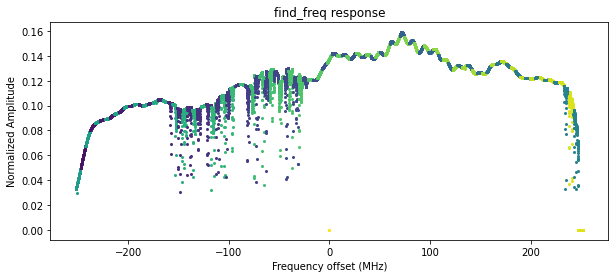

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 array([[0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
        ...,
        [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j]]))

In [38]:
#This does a VNA type sweep in the specified band
#Note that the resolution is poor (default is 2kHz)
S.find_freq(band, tone_power=band_cfg['drive'], make_plot=True, show_plot=True, save_plot=True)

In the case where you already have a tunefile, you just need to run load_tune and relock instead of doing a full `find_freq`. 

**If you have already run `find_freq` you can skip the above cell and instead run the following**

In [56]:
band = 2
band_cfg = cfg.dev.bands[band]
S.load_tune()
S.relock(band)

### [Setup notches](https://pysmurf.readthedocs.io/en/main/client/tune.html?highlight=setup_notches#pysmurf.client.tune.smurf_tune.SmurfTuneMixin.setup_notches)
Does a fine sweep over the resonances found in find_freq. This information is used for placing tones onto resonators. It is recommended that you follow this up with run_serial_gradient_descent() afterwards.

We're using the following optional parameters:
- **tone_power** Same as in `find_freq`
- **new_master_assignment**  True, this is the mapping between frequency and smurf channel. If you change things
  that will shift the resonator (like temperature, power, detector bias) then your
  frequencies can be slightly off so they may not map to the same smurf channels. If you
  want them to map to the same smurf channels you should set new_master_assignment to
  False. Typical operation is to run with True the first time then false all times after
  that.Whether to create a new master assignment file. This file defines the mapping between resonator frequency and channel number.

`setup_notches` outputs a tunefile. You can get this tunefile by running S.tune_file this returns a string 
with the path to the tunefile. If you have this tunefile then you shouldn't have to run find_freq + 
setup_notches again even if you have to restart the system instead you can run S.load_tune(tunefile) 
followed by S.relock(band).

We can then run [plot_tune_summary](https://pysmurf.readthedocs.io/en/main/client/tune.html?highlight=setup_notches#pysmurf.client.tune.smurf_tune.SmurfTuneMixin.plot_tune_summary) to produce summary plots of the tuning procedure. We run with `eta_scan=True` to generaet the ellipse plots

In [17]:
S.setup_notches(band,tone_power=band_cfg['drive'],new_master_assignment = True)

We can then run [plot_tune_summary](https://pysmurf.readthedocs.io/en/main/client/tune.html?highlight=setup_notches#pysmurf.client.tune.smurf_tune.SmurfTuneMixin.plot_tune_summary) to produce summary plots of the tuning procedure. We run with `eta_scan=True` to generate the ellipse plots

/data/smurf_data/tune/1606974636_tune.npy


/usr/local/src/pysmurf/python/pysmurf/client/tune/smurf_tune.py:1390: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig = plt.figure(figsize=(9,4.5))


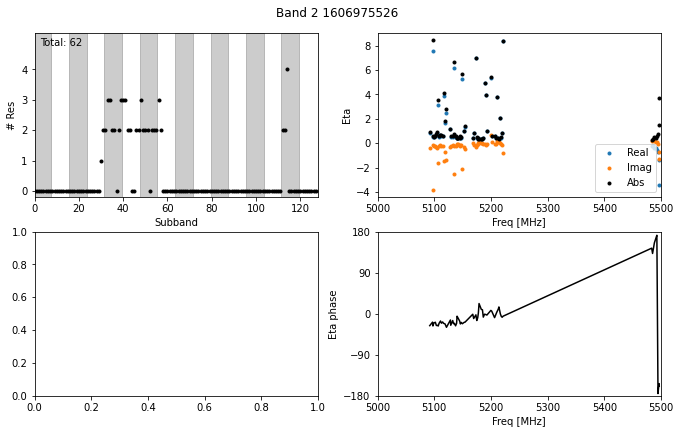

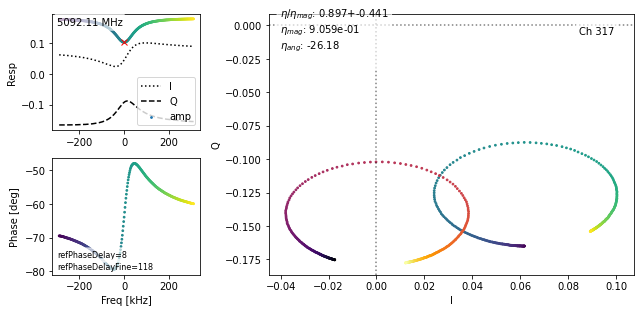

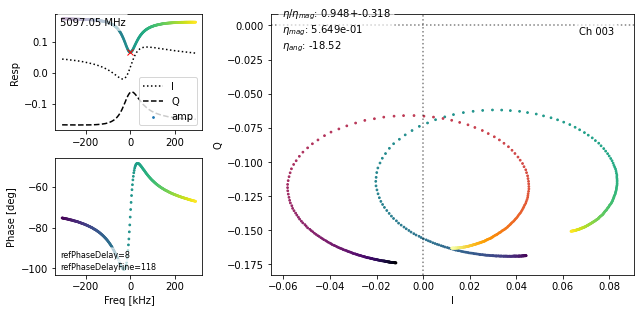

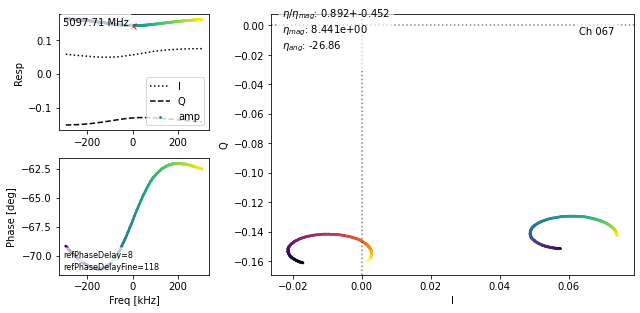

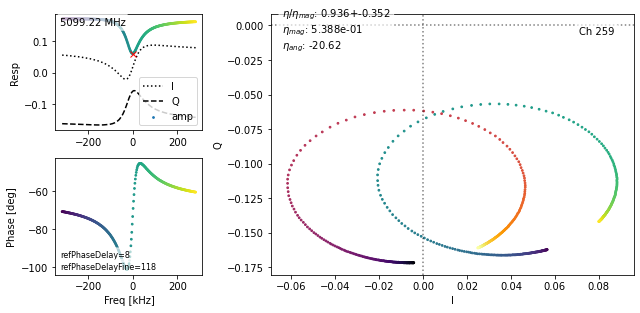

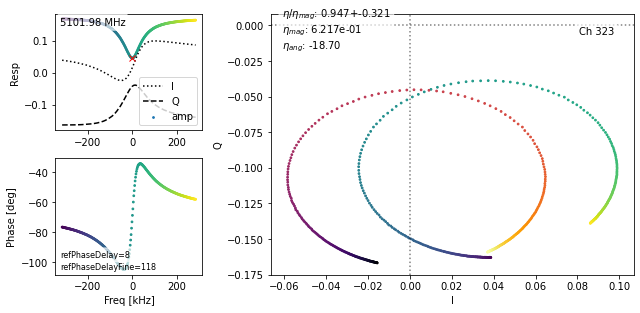

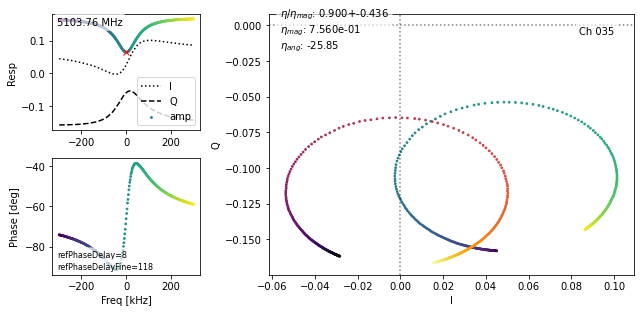

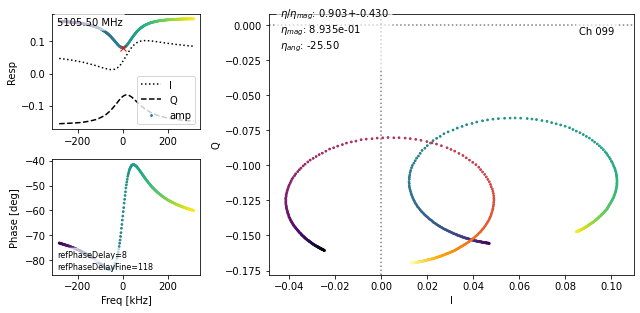

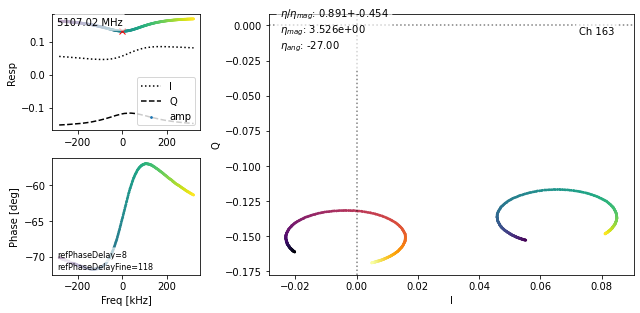

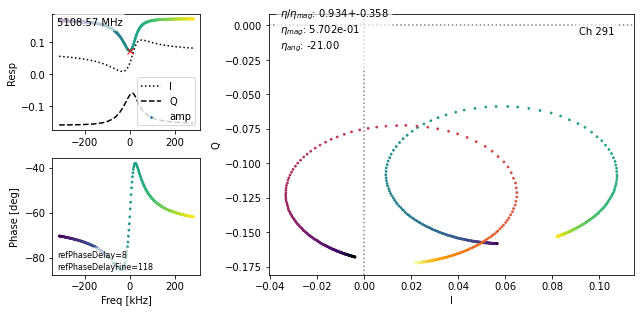

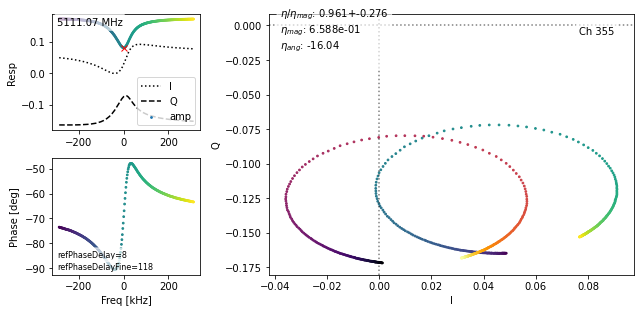

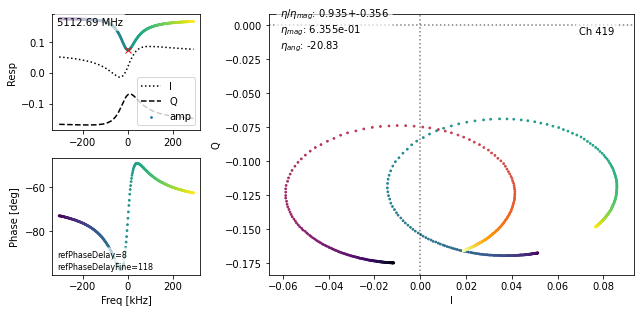

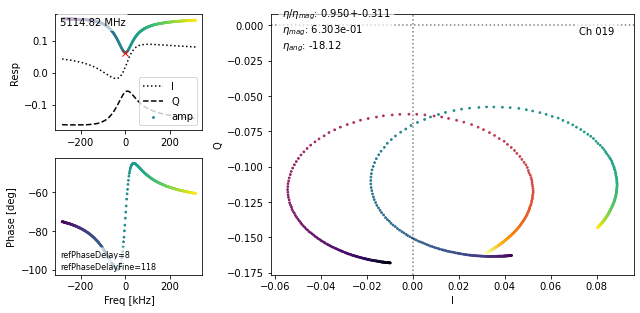

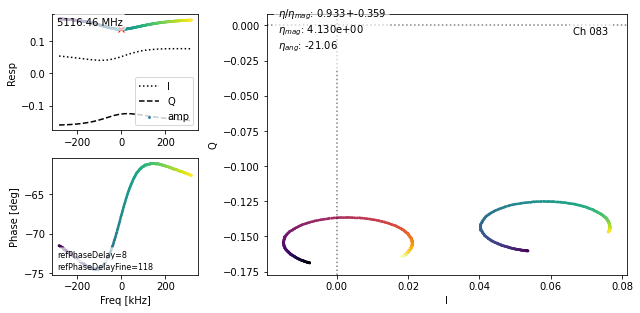

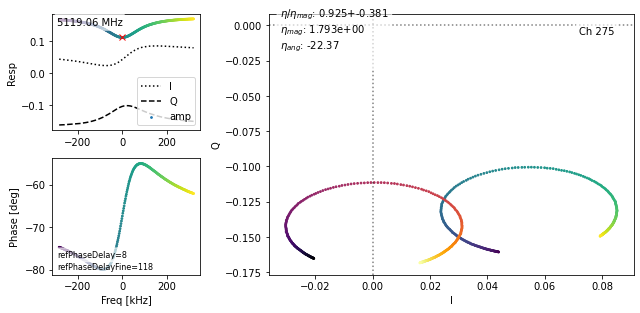

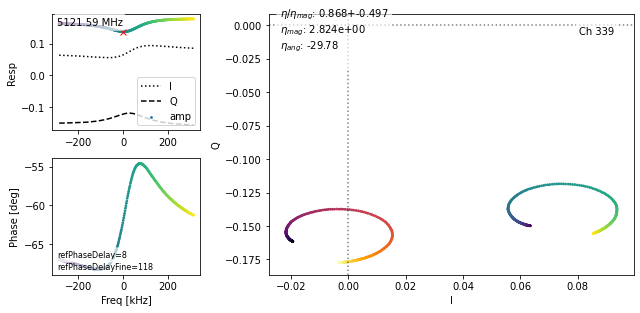

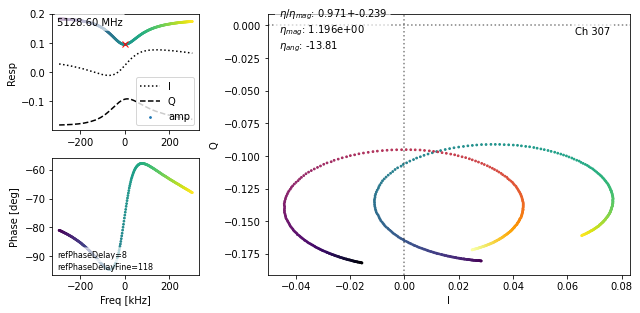

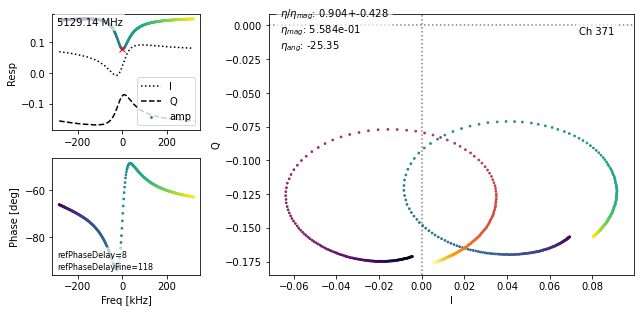

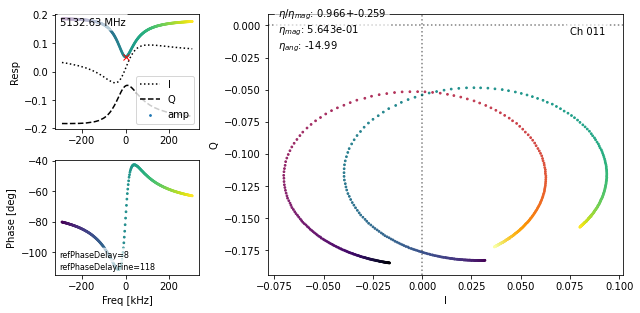

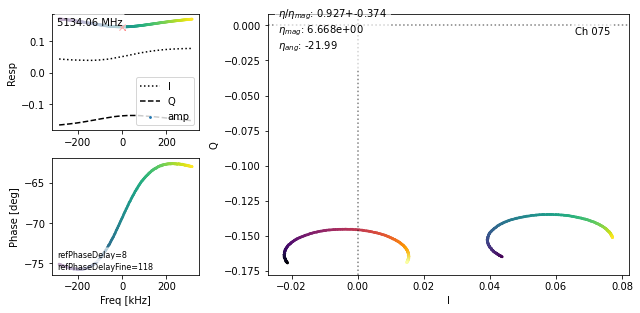

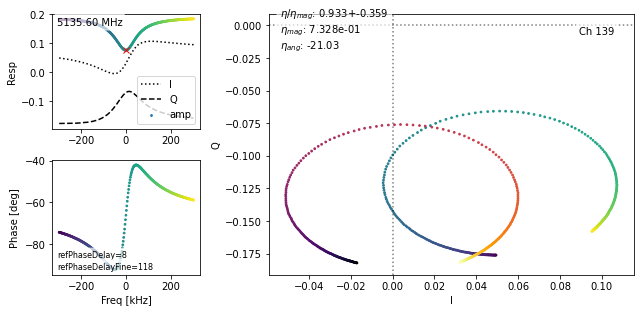

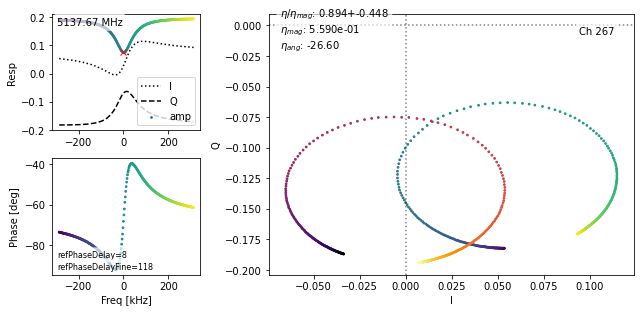

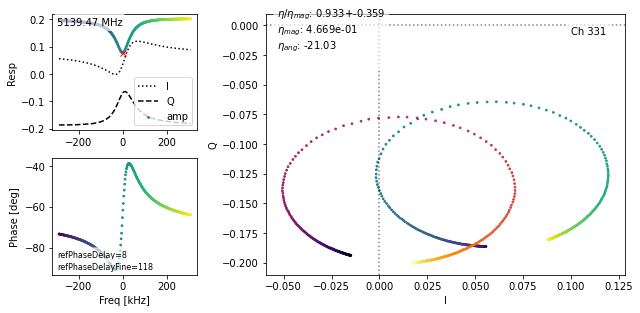

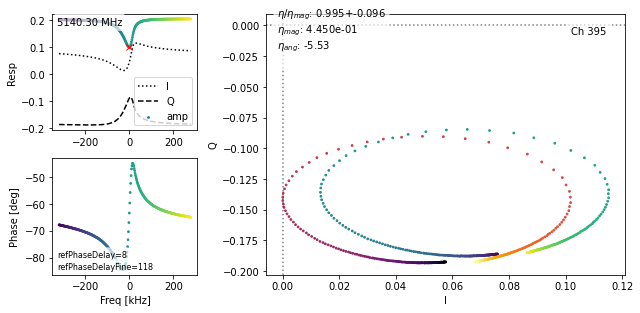

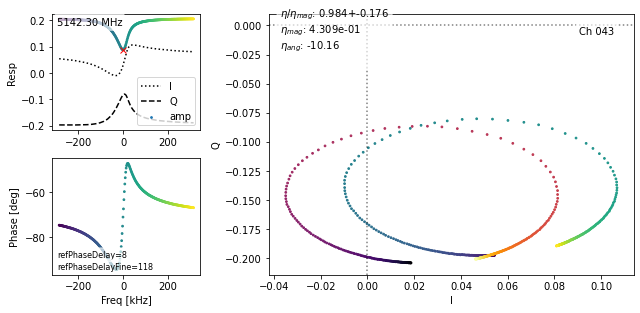

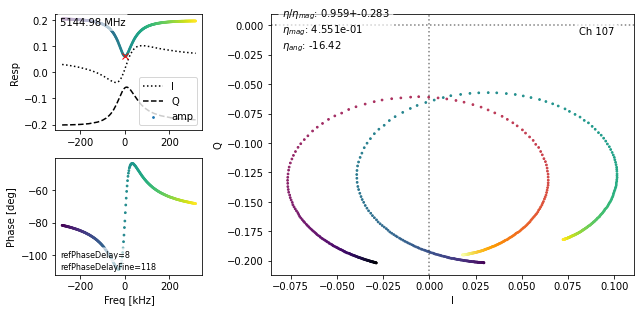

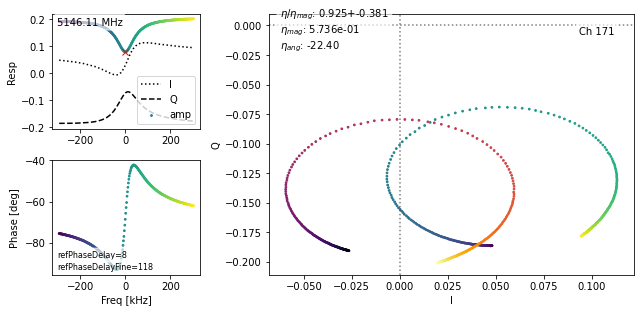

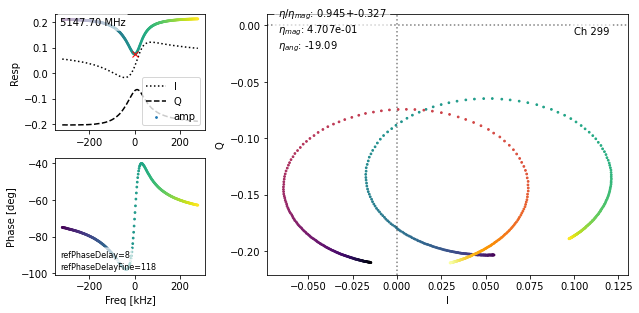

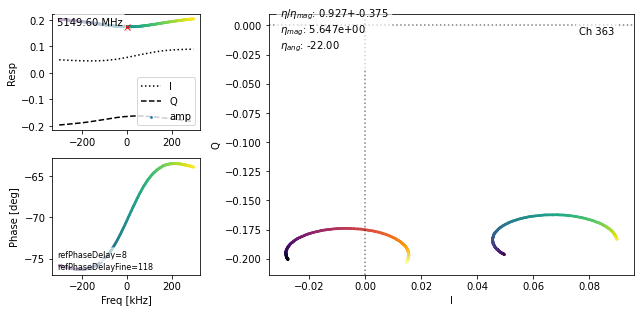

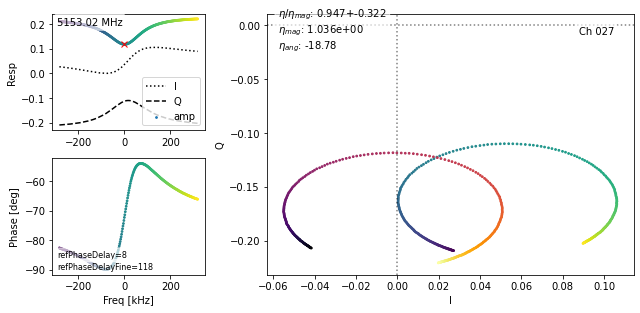

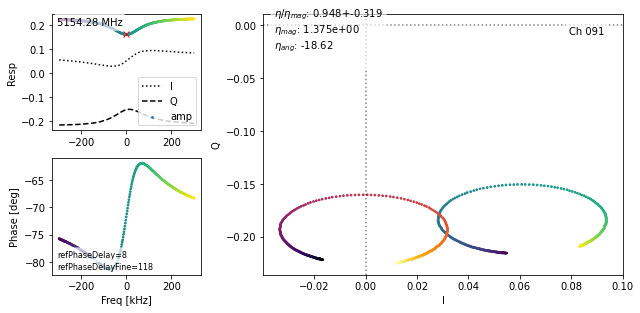

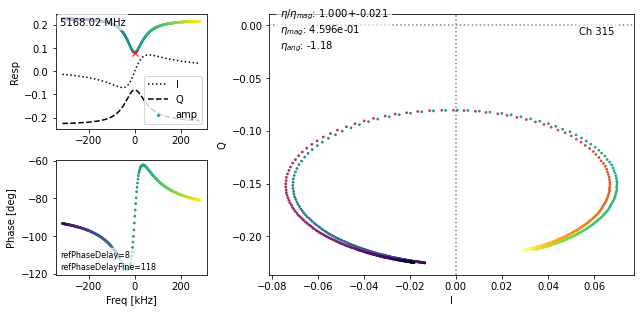

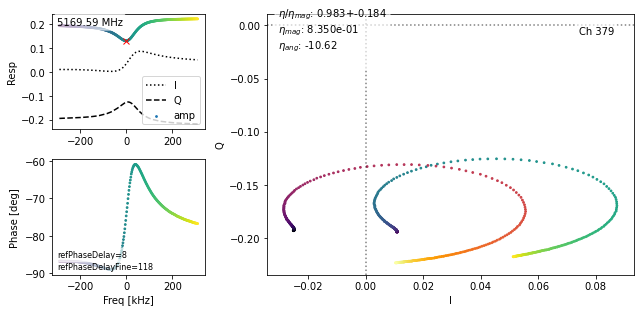

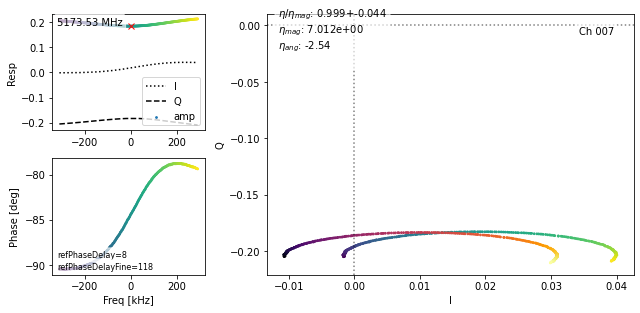

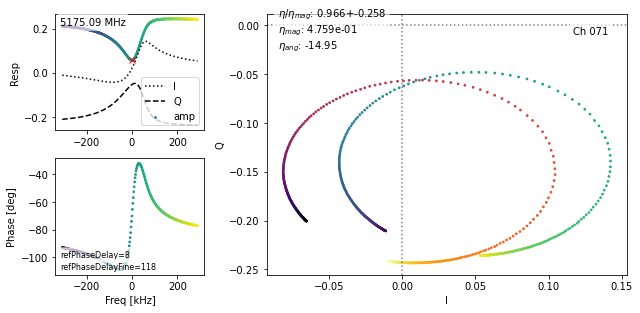

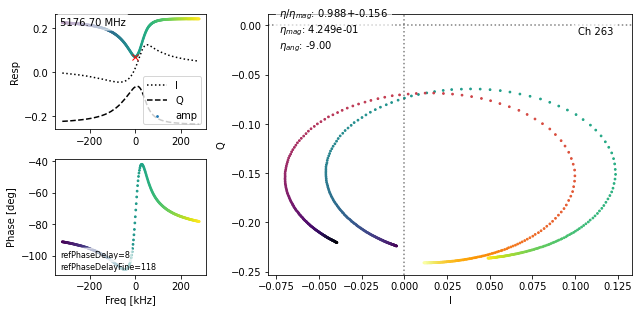

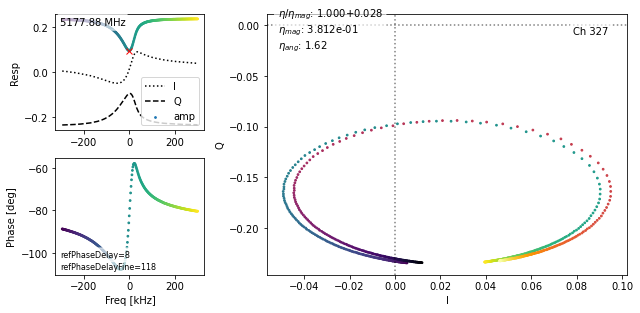

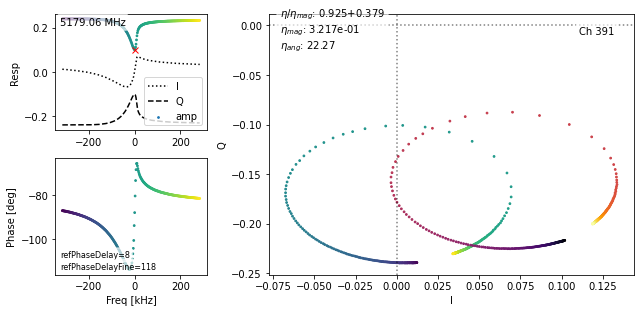

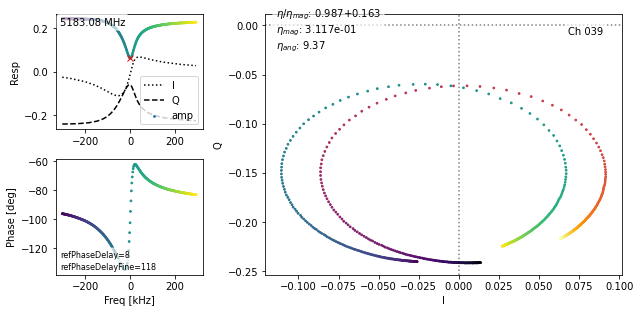

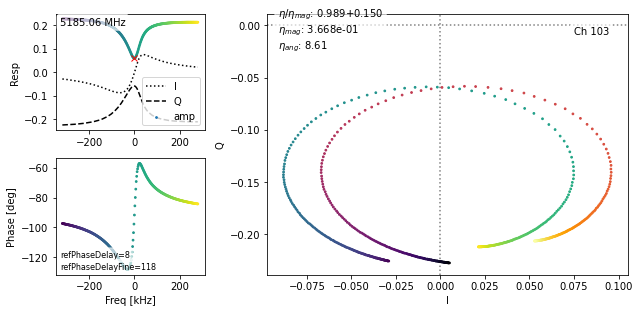

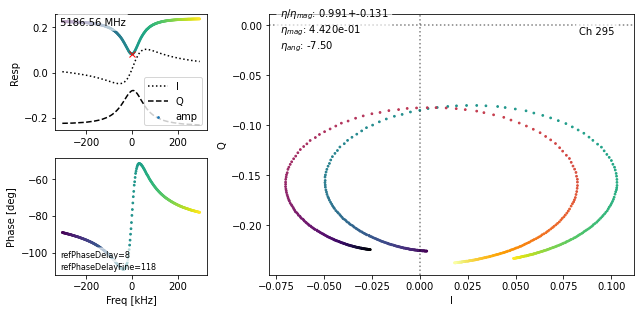

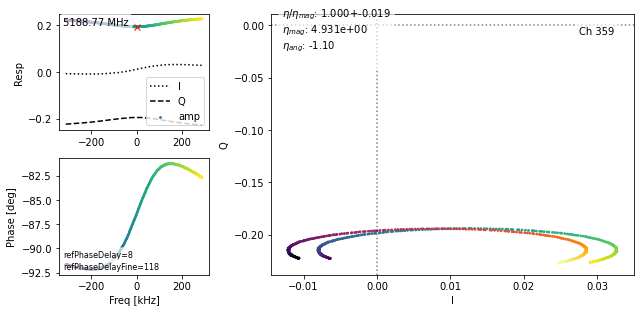

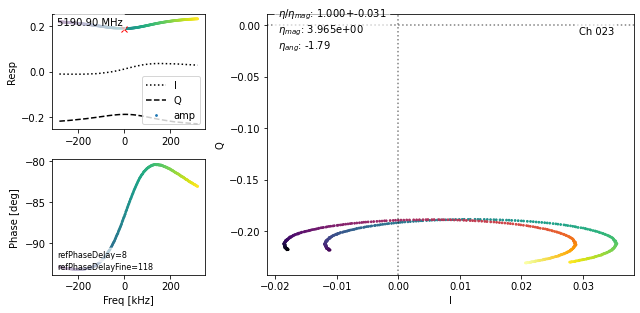

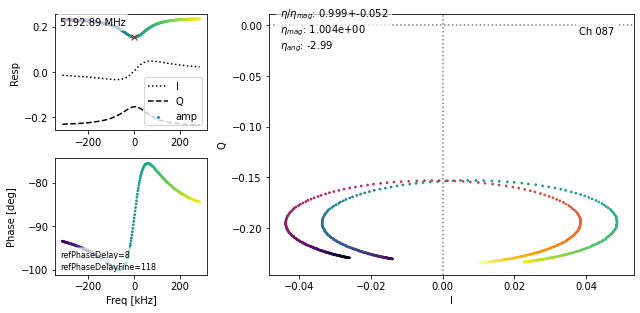

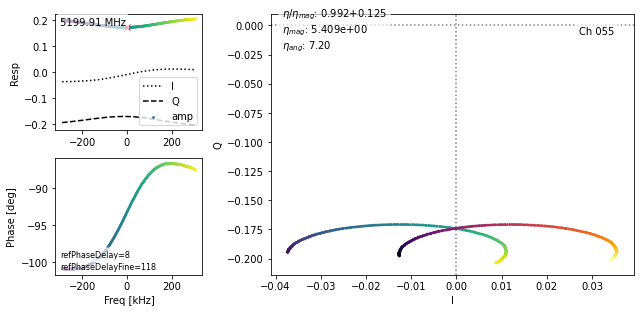

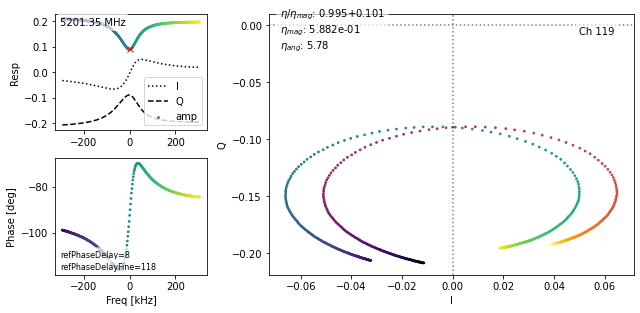

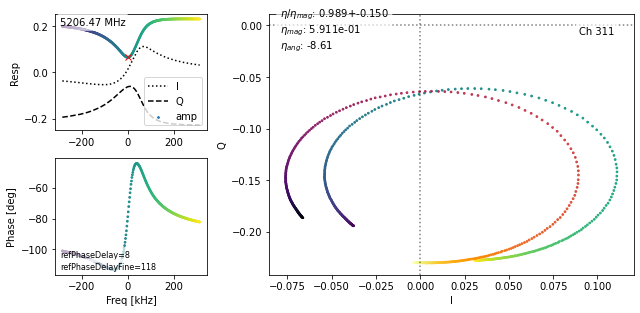

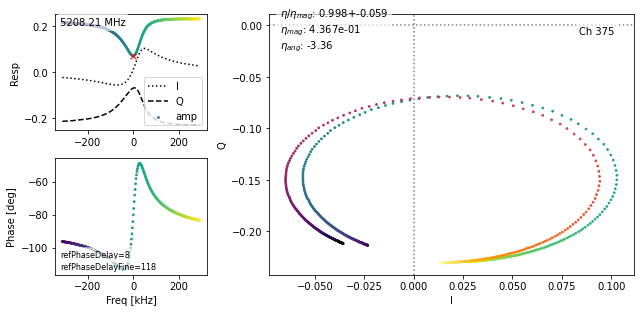

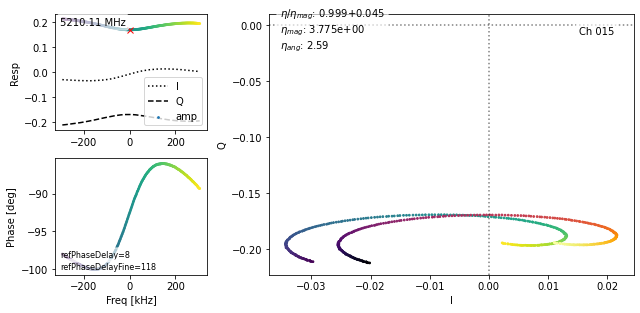

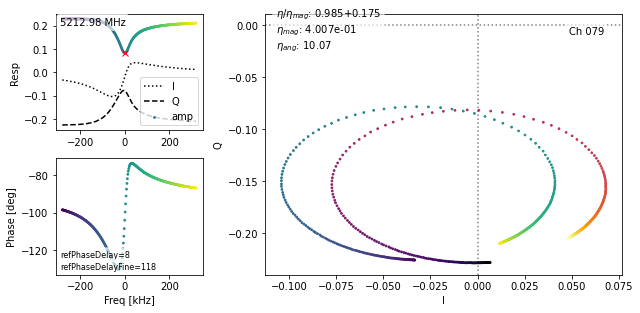

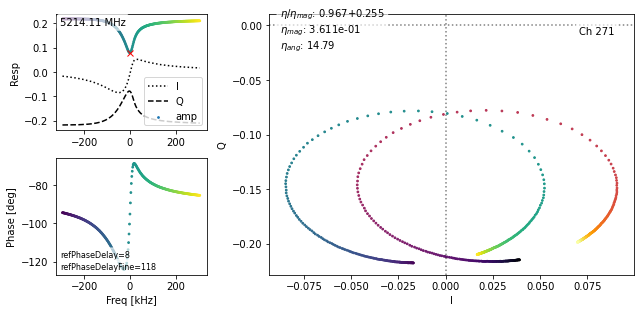

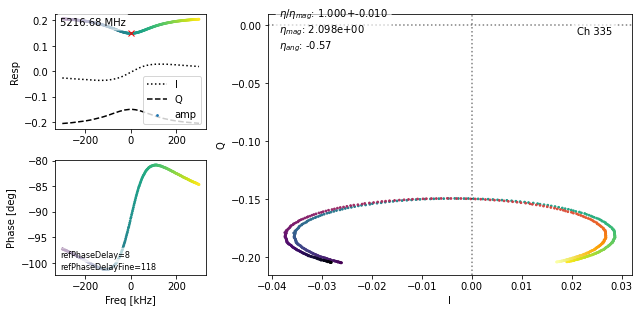

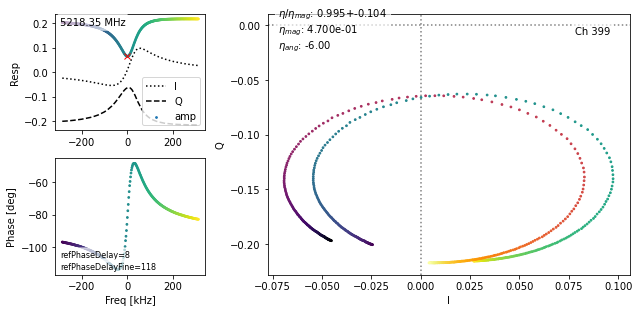

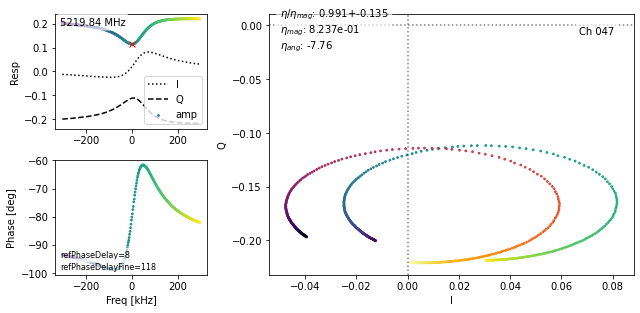

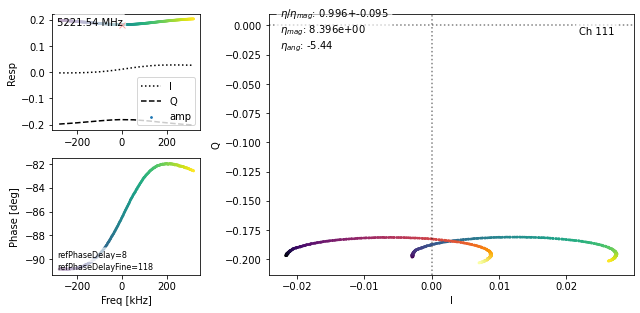

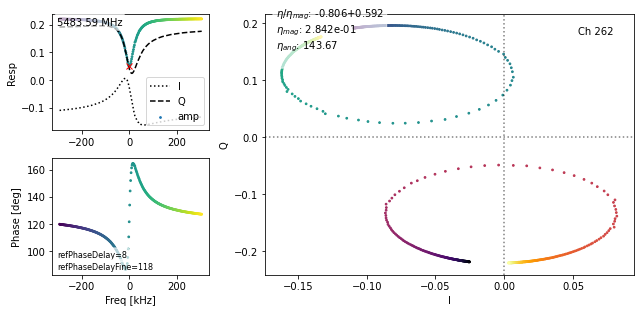

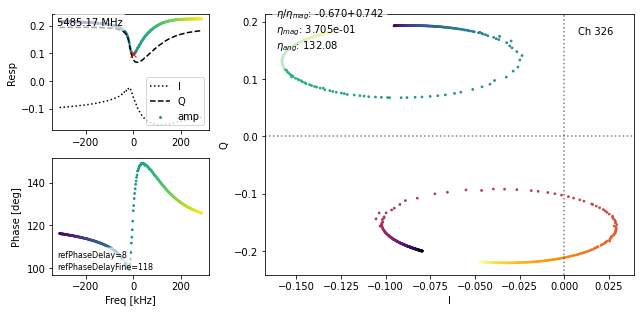

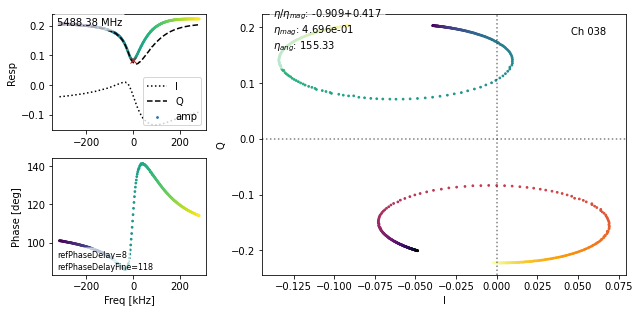

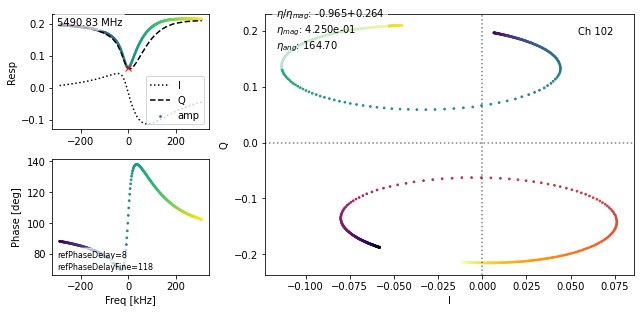

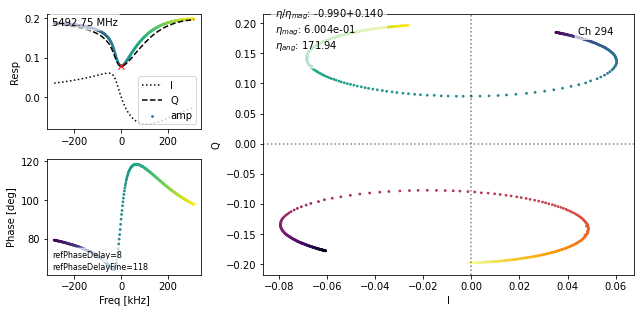

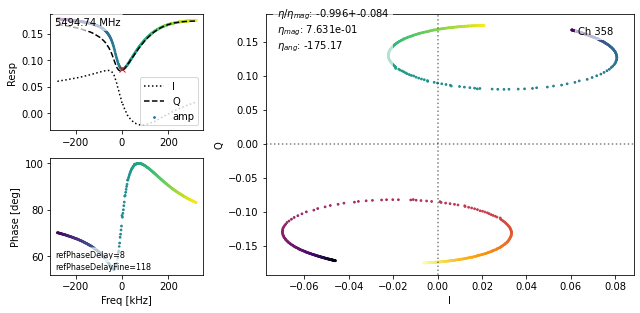

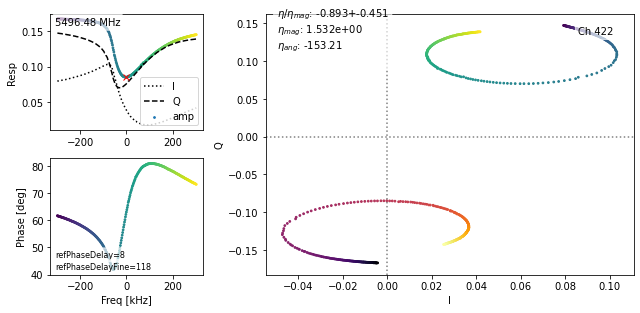

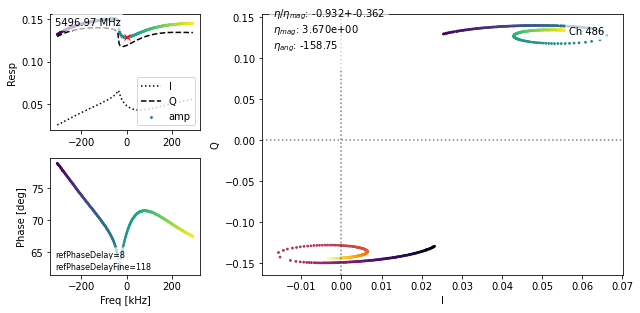

In [46]:
print(S.tune_file)
S.plot_tune_summary(band, eta_scan=True,show_plot = True)

The resonator tracking parameter is referred to as "eta". It is a single complex number that gives the phase and width of the resonator. We will begin to discuss things in terms of I and Q, the quadrature decomposition of the signal. I is the in phase component, and Q is the quadrature (90 deg out of phase) component. The eta parameter is designed to rotate the resonator response at the minima into Q. We will show a plot of this soon.

![graphic1](./example_pics/Eta_Resp_Plots.png)

in this graphic you can see what the resonator response looks like vs frequency in magnitude/phase and real/imaginary. The red x corresponds to the minimum of the abs(resp).

![graphic2](./example_pics/Eta_Rotation_Explanation.png)

Here we have plotted the same data as above but with the axes real (I) vs imaginary (Q) and the different dots in the "ellipse" are the different frequencies we acquired complex response data at. Over top of this we have plotted the same red x for the minimum of the abs(resp) and an orange and greeen star showing where we calculate the complex vector we call eta. The angle (labeled theta here) is by how much we rotate the data such that small frequency shifts about the red x all show up in 1 quadrature. The magnitude of the vector gives us the conversion from voltage measured in one quadrature (after rotation) to frequency shift. Setup_notches and serial_gradient_descent w/ serial_eta_scan are the functions that find the resonance frequency (red x) and calculate the eta parameter (magnitude and phase) at that resonance frequency.

In [57]:
for _ in range(2):
    S.run_serial_gradient_descent(band)
    S.run_serial_eta_scan(band)

These serial algorithms must always be run after `setup_notches`, or `relock`.

# Hardware aside : the RTM flux ramp monitor port

To help diagnose flux ramp issues, a buffered single-ended pick-off of the flux ramp signal before it goes into the cable to the cryostat card is provided on a LEMO connector on the back of the RTM board.  There are 5x LEMO connectors (1x of which is 2-pin) on the back of the RTM.  Looking at the RTM front plate, the flux ramp monitor LEMO port is the one in the bottom right.  Here's a picture of those LEMO connectors on the back of the RTM, with a BNC cable connected to the flux ramp monitor port through a BNC->LEMO adapter:<br>
<img style="transform: rotate(0deg); width:1000px" src="setup_pics/rtm_flux_ramp_monitor.JPG" alt="RTM Flux Ramp Monitor Port" title="RTM Flux Ramp Monitor Port" /><br>

When sending the flux ramp signal in this notebook, here's what the output looks like on an oscilloscope, triggering on the flux ramp signal (50Ohm terminated):
<img style="transform: rotate(0deg); width:600px" src="setup_pics/rtm_flux_ramp_monitor_trace.png" alt="RTM Flux Ramp Monitor Trace" title="RTM Flux Ramp Monitor Trace" />

If you're not sending a flux ramp signal, you'll see nothing on the flux ramp monitor port.  Because it's picked off before the filtering and final attenuation on the cryostat card, the signal is much bigger and easier to trigger on.  If you suspect your flux ramp isn't working, this is the first thing to check.

The other LEMO connectors on the back of the RTM are less useful in typical testing.  The bipolar flux ramp signal can be redirected from the cable to the cryostat card and onto the stand-alone 2-pin LEMO connector using jumpers (JMP1 & JMP2) on the RTM.

# Tracking

Now that the resonators are rotated into Q-only, the system must track the tones. Input power onto the TES changes the characteristic impedance of the resonator circuit and shifts the resonances up and down in frequency. We monitor this change by coupling the resonators to an RF SQUID.

To avoid TLS noise, we shift the signal up in frequency by flux ramping the SQUIDs. SQUIDs have a periodic V-phi curve, so if you pass enough voltage across a SQUID, it will trace out an approximately sinusoidal response. The flux ramp is a triangle wave. 

The following graphic is a nice schematic picture of how this works. The top pane shows the sawtooth flux ramp signal that is fed into the SQUID via a transformer we call the "flux ramp input coil". The second pane shows a dumby signal from a TES which is coupled in through a separate transformer that we call the "TES input coil". You see initially there no signal from the TES initially (blue), then a step up and there's some signal from the TES (red), then another step and there's twice as much signal from the TES (green). The bottom pane shows the resonators center frequency as a function of time. The squid is periodic with flux with a period equal to one [flux quantum](https://en.wikipedia.org/wiki/Magnetic_flux_quantum) ($\Phi_0$) so the modulation frequency in the bottom pane is equal to the frequency of the ramp signal ($f_{\mathrm{FR}}$) times the number of $\Phi_0$'s per ramp ($N_{\Phi_0}$ i.e. the ramp amplitude). In this example the flux ramp has a period of 50$\mu$S so $f_{\mathrm{FR}}$ = 20kHz and the $N_{\Phi_0}$ = 5, so the frequency in the bottom pane is modulating at 100kHz. When some signal is coupled into the SQUID from the TES on the TES input coil the modulation function is just phase shifted (the dashed lines show the modulation function if there was no added flux from the TES), because the timescale of those signals are << 100kHz ($\mathcal{O}(100Hz)$). 

![graphic](./example_pics/Flux_Ramp_Response.png)

Tracking setup configures the "tracking algorithm". The following schematic shows a cartoon version of what it does:

![graphic](./example_pics/Tracking_Algorithm_Schematic.png)

The algorithm moves the tones around in a smart way by knowing that the SQUID will be modulating at a particular frequency it can programs the tones to move following a sine wave of that frequency (plus it's harmonics). The phase of the first harmonic is then what's streamed to us when we're tracking (because that's what encodes the TES signal).

In order for that algorithm to work properly though you need to know your tracking frequency well and choose parameters for your flux ramp (amplitude, and frequency) that are reasonable. We typically start by tracking at 20kHz (this is the piece thats $N_{\Phi_0}\times f_{\mathrm{FR}}$, and it could be greater or smaller than 20 kHz but you would follow the same steps), and we usually start by setting our flux ramp frequency $f_{\mathrm{FR}}$ at 4kHz which leaves us to find what amplitude of our ramp corresponds to 5 $\Phi_0$s.

In pysmurf the frequency the algorith tracks at is called `lms_freq_hz`, the amplitude of the ramp is `fraction_full_scale` (which is in units of fractions of the full scale of the DAC that's generating the ramp signal), and the ramp rate is called `reset_rate_khz`.

There is a nice optional argument built into the tracking_setup algorithm that will calculate the tracking frequency for you. To use this you set `meas_lms_freq` = True and `lms_freq_hz` = None.

## Calculating `frac_pp` and `lms_freq_hz`
Here we set the ramp rate (`reset_rate_khz`) = 4kHz and the `fraction_full_scale` = 0.2 then calculate the `lms_freq_hz` that this corresponds to. From this we can adjust `fraction_full_scall` until we get our desired `lms_freq_hz` = 20000.

We're using the following optional parameters:
- **make_plot**, and **show_plot** are self explanatory
- **channel** is a list channels to make individual channel plots for. Since we set an empty list not plots will be made
- **nsamp** set to $2^{18}$ is the number of samples acquired during the tracking_setup algorithm (i.e. length of the trace)
- **feedback_start/end_frac** set where the feedback will actually be enabled, sometimes there is a transient around where the ramp resets (sawtooth edge) so this allows you to effectively mask out this transient. For example if you have 5 phi_0's per ramp and you want to mask out the first phi_0 you would sent feedback_start_frac = 0.2 

(array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.00011845],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.00012074],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.00012302],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.00017796],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.00018024],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.00018253]]),
 array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.00012074],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.00012302],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.00012531],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.00018024],
        [0. 

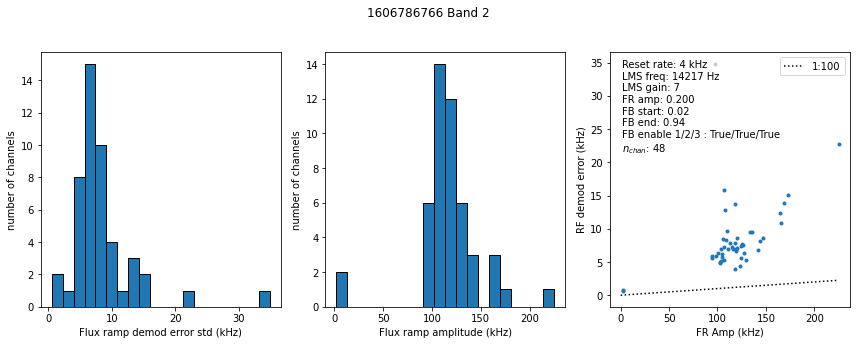

In [43]:
S.tracking_setup(band, reset_rate_khz=4,lms_freq_hz=None,meas_lms_freq=True,fraction_full_scale=.2,
                 make_plot=True,show_plot=True,channel=[],nsamp=2**18,
                 feedback_start_frac=0.02,feedback_end_frac=0.94)

The output summary plot shows 3 subplots:
* (left) histogram of the tracking error (you want this to be small for good channels)
* (center) histogram of the peak-to-peak frequency shift of the squid modulation (should be ~100kHz for our chips)
* (right) Scatter plot of tracking error vs peak-to-peak frequency shift populations far to the right or left on this plot and with large error are not tracking properly

To find the `lms_freq_hz` that was calculated from this last call to `tracking_setup` you can run the following:

In [44]:
meas_lms_hz = S.get_lms_freq_hz(band)
print(meas_lms_hz)

14216.423034667969


Now we need to adjust our `fraction_full_scale` parameter so that we can track at 20kHz instead of `meas_lms_hz` this is just a little algebra 
$$
\mathrm{frac_{pp}} = \mathrm{frac_{pp, guess}}*\frac{N_\Phi\times f_{FR}}{f_\mathrm{meas}}. 
$$
Sometimes to get a better measurement of `meas_lms_hz` I will rerun `tracking_setup` in the measure mode as above but after I have killed channels that are tracking poorly (we will show how to identify and kill bad channels in a few ways below) since poorly tracking channels can skew the estimate of the optimal tracking frequency. Also how well you are centered on the resonator minimum greatly effects the tracking (see section on tuning).

Now assuming we've optimized our fraction_full_scale for 20kHz lms_freq let's rerun tracking_setup but not in measure mode:

(array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.00015965],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.00016193],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.00016422],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.00022144],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.00022373],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.00022602]]),
 array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.00015965],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.00016193],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.00016422],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.00022144],
        [0. 

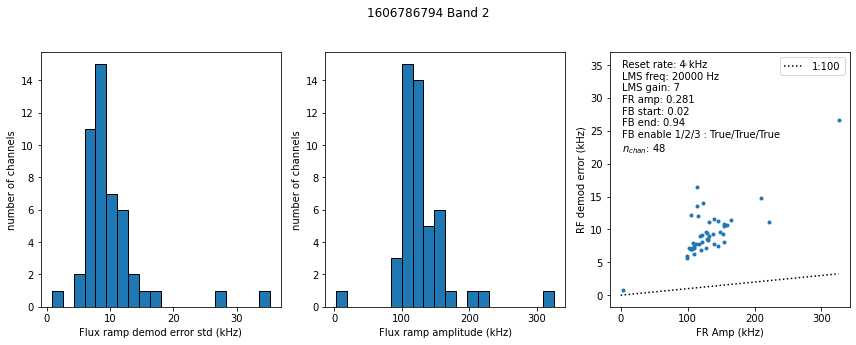

In [45]:
S.tracking_setup(band,reset_rate_khz=4,lms_freq_hz=20000,meas_lms_freq=False,
                 fraction_full_scale=.2*(20000/meas_lms_hz),make_plot=True,show_plot=True,
                 channel=[],nsamp=2**18,feedback_start_frac=0.02,feedback_end_frac=0.94)